In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/financial-sentiment-analysis/data.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_csv("/kaggle/input/financial-sentiment-analysis/data.csv")

In [5]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


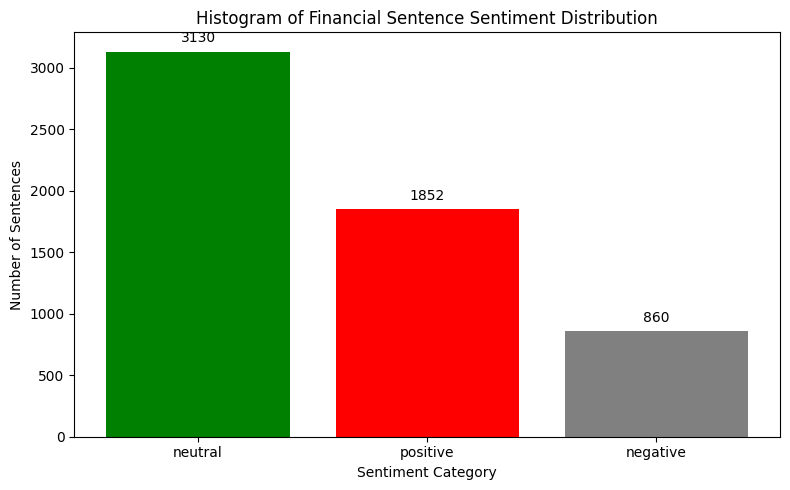

In [8]:
sentiment_counts = df["Sentiment"].value_counts()
print(sentiment_counts)
plt.figure(figsize=(8,5))
bars = plt.bar (sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, yval,
             ha='center', va='bottom')

plt.xlabel("Sentiment Category")
plt.ylabel("Number of Sentences")
plt.title("Histogram of Financial Sentence Sentiment Distribution")
plt.tight_layout()
plt.show()


In [19]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

# =========================
# Config
# =========================
CSV_PATH = "/kaggle/input/financial-sentiment-analysis/data.csv"   # your dataset path
TEXT_COL = "Sentence"                  # column with text
LABEL_COL = "Sentiment"                # column with labels
MODEL_NAME = "ProsusAI/finbert"        # finance-tuned transformer
OUTPUT_DIR = "./finbert-financial-sentiment"

# =========================
# Device (GPU if available)
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# =========================
# Load and validate data
# =========================
df = pd.read_csv(CSV_PATH)

# Ensure required columns exist
assert isinstance(TEXT_COL, str) and isinstance(LABEL_COL, str), "TEXT_COL and LABEL_COL must be strings."
assert TEXT_COL in df.columns and LABEL_COL in df.columns, f"CSV must contain '{TEXT_COL}' and '{LABEL_COL}'."

# Normalize labels to strings, strip, and lowercase
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

# Keep only the three classes
allowed = {"neutral", "positive", "negative"}
df = df[df[LABEL_COL].isin(allowed)].copy()

# Map labels to ids (consistent ordering)
label2id = {"neutral": 0, "positive": 1, "negative": 2}
id2label = {v: k for k, v in label2id.items()}
df["label"] = df[LABEL_COL].map(label2id)

print("Class distribution:")
print(df[LABEL_COL].value_counts())



Using device: cuda
Class distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


In [66]:
import os 
import inspect 
import pandas as pd
import torch 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
accuracy_score,
precision_recall_fscore_support,
classification_report,
confusion_matrix
)

from transformers import (
AutoTokenizer,
AutoModelForSequenceClassification,
Trainer,
TrainingArguments
)

from datasets import Dataset

In [68]:
CSV_PATH = "/kaggle/input/financial-sentiment-analysis/data.csv"
TEXT_COL= "Sentence"
LABEL_COL = "Sentiment"
MODEL_NAME= "ProsusAI/finbert"
OUTPUT_DIR = "./finbert-financial-sentiment"

In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print (f"using device: {device}")

using device: cuda


In [70]:
df = pd.read_csv(CSV_PATH)
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [71]:
assert isinstance(TEXT_COL, str) and isinstance (LABEL_COL,str), "all must be string"

In [72]:
assert TEXT_COL in df.columns and LABEL_COL in df.columns, "must contain"

In [73]:
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
allowed = {"neutral","positive","negative"}
df= df[df[LABEL_COL].isin(allowed)].copy()
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [74]:
label2id = {"neutral": 0, "positive":1, "negative":2}
id2label = {v:k for k, v in label2id.items()}
print(id2label)

{0: 'neutral', 1: 'positive', 2: 'negative'}


In [75]:
df["label"] = df[LABEL_COL].map(label2id)
df.head()

,Sentence,Sentiment,label
0,The GeoSolutions technology will leverage Bene...,positive,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,2
2,"For the last quarter of 2010 , Componenta 's n...",positive,1
3,According to the Finnish-Russian Chamber of Co...,neutral,0
4,The Swedish buyout firm has sold its remaining...,neutral,0


In [76]:
print(f"class distribution : {df[LABEL_COL].value_counts()}")

class distribution : Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


In [77]:
train_df, test_df = train_test_split (
    df,
    test_size =0.2,
    random_state = 42,
    stratify = df["label"]
)

In [80]:
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, "label"]])
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, "label"]])

In [79]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

BertTokenizerFast(name_or_path='ProsusAI/finbert', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [82]:
def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COL],
        padding="max_length",
        truncation=True,
        max_length=128
    )



In [83]:
train_ds = train_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)
train_ds

Map:   0%|          | 0/4673 [00:00<?, ? examples/s]

Map:   0%|          | 0/1169 [00:00<?, ? examples/s]

Dataset({
    features: ['Sentence', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4673
})

In [84]:
cols = ["input_ids", "attention_mask", "label"]
train_ds = train_ds.remove_columns([TEXT_COL]).with_format("torch", columns=cols)
test_ds  = test_ds.remove_columns([TEXT_COL]).with_format("torch", columns=cols)

In [85]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)


In [87]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }


In [92]:
sig = inspect.signature(TrainingArguments.__init__)
supported = set(sig.parameters.keys())

args = {
    "output_dir": OUTPUT_DIR,
    "num_train_epochs": 10,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 32,
    "learning_rate": 2e-5,
}

# Add conditionally supported arguments
if "evaluation_strategy" in supported:
    args["evaluation_strategy"] = "epoch"
elif "eval_strategy" in supported:
    # Some very old versions used 'eval_strategy'
    args["eval_strategy"] = "epoch"
elif "evaluate_during_training" in supported:
    # Very old fallback (deprecated)
    args["evaluate_during_training"] = True

if "save_strategy" in supported:
    args["save_strategy"] = "epoch"
if "logging_strategy" in supported:
    args["logging_strategy"] = "steps"
    args["logging_steps"] = 50
elif "logging_steps" in supported:
    args["logging_steps"] = 50

if "load_best_model_at_end" in supported:
    args["load_best_model_at_end"] = True
if "metric_for_best_model" in supported:
    args["metric_for_best_model"] = "f1_weighted"
if "greater_is_better" in supported:
    args["greater_is_better"] = True
if "fp16" in supported and torch.cuda.is_available():
    args["fp16"] = True
if "report_to" in supported:
    args["report_to"] = "none"

training_args = TrainingArguments(**args)


In [93]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_55/1382228127.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [94]:
train_result = trainer.train()
print("Training completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.535600,0.467061,0.779299,0.802225,0.779299,0.786081
2,0.413000,0.430063,0.799829,0.797752,0.799829,0.798584
3,0.293900,0.500940,0.789564,0.805031,0.789564,0.795397
4,0.211900,0.579550,0.801540,0.824663,0.801540,0.809143
5,0.156400,0.630682,0.813516,0.809563,0.813516,0.790315
6,0.149100,0.718023,0.786997,0.775103,0.786997,0.778361
7,0.107000,0.728029,0.784431,0.804981,0.784431,0.792044
8,0.159500,0.780591,0.800684,0.787144,0.800684,0.785559
9,0.140300,0.813562,0.778443,0.788932,0.778443,0.782951
10,0.116000,0.836416,0.773311,0.776193,0.773311,0.774672


Training completed.


In [95]:
eval_result = trainer.evaluate()
print("Eval metrics:", eval_result)


Eval metrics: {'eval_loss': 0.5795496106147766, 'eval_accuracy': 0.8015397775876818, 'eval_precision_weighted': 0.8246634610502314, 'eval_recall_weighted': 0.8015397775876818, 'eval_f1_weighted': 0.8091430729879342, 'eval_runtime': 4.061, 'eval_samples_per_second': 287.857, 'eval_steps_per_second': 9.111, 'epoch': 10.0}


In [96]:

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)

print("\nClassification report:")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(3)],
    digits=4
))

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))




Classification report:
              precision    recall  f1-score   support

     neutral     0.8730    0.7907    0.8298       626
    positive     0.8908    0.8571    0.8736       371
    negative     0.5061    0.7209    0.5947       172

    accuracy                         0.8015      1169
   macro avg     0.7566    0.7896    0.7661      1169
weighted avg     0.8247    0.8015    0.8091      1169


Confusion matrix (rows=true, cols=pred):
[[495  28 103]
 [ 35 318  18]
 [ 37  11 124]]


In [97]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Model saved to ./finbert-financial-sentiment


In [103]:
example_texts = [
    "Net sales decreased by 25% year-over-year.",
    "$ESI on ups, up $1.50 to $2.50 BK a real possibility",
    "According to the Chamber, all the major firms remained stable."
]
enc = tokenizer(
    example_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
).to(device)

with torch.no_grad():
    out = model(**enc)

pred_labels = torch.argmax(out.logits, dim=-1).cpu().numpy()
print("\nPredictions for examples:")
for text, lid in zip(example_texts, pred_labels):
    print(f"- {text} => {id2label[int(lid)]}")



Predictions for examples:
- Net sales decreased by 25% year-over-year. => negative
- $ESI on ups, up $1.50 to $2.50 BK a real possibility => positive
- According to the Chamber, all the major firms remained stable. => neutral
